# Model

In this notebook, we build a set of models to predict IMD in 2019 and compare them.

In [1]:
%matplotlib inline
import numpy as np
import pandas
import geopandas
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

## Data

In [2]:
# Read data
imd = pandas.read_csv('imd.csv', index_col='LSOA21CD')
socio = pandas.read_csv('Socioeconomic.csv', index_col='LSOA21CD')
manual = pandas.read_csv('landsat_features.csv', index_col='LSOA21CD')
lsoa = geopandas.read_file('uk_lsoa_london_embeds_2020.geojson').set_index('LSOA21CD')

# Column names and easy handles
embed_cols = [c for c in lsoa.columns if c.startswith('A') and c.endswith('_mean')]
embeds = pandas.DataFrame(lsoa[embed_cols])
socio_cols = [c for c in socio.columns if c != 'IMD_decile']

y = imd['imd19_score']
train = imd['train_test'] == 'train'

ERROR 1: PROJ: proj_create_from_database: Open of /opt/conda/envs/gds/share/proj failed


## Setup

We use a pre-defined spatial train/test split based on a regular grid overlaid on London (stored in `imd.csv`). Training LSOAs come from 80% of grid blocks; the remaining 20% are held out for testing. All models are fitted on training LSOAs and evaluated on test LSOAs using RMSE and $R^2$.

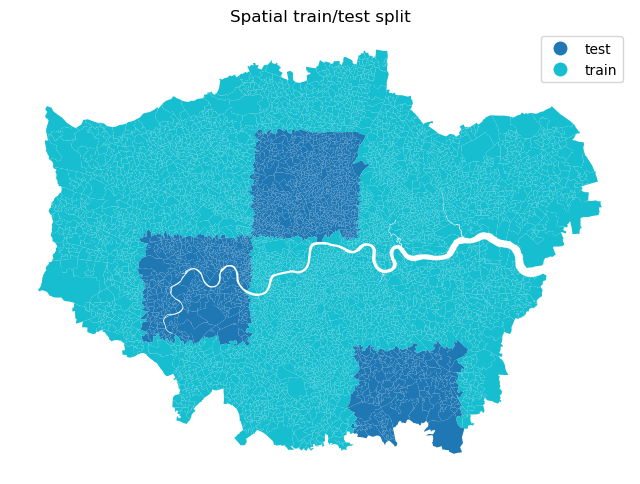

In [3]:
fig, ax = plt.subplots(figsize=(8, 8))
lsoa.join(imd[['train_test']]).plot(
    column='train_test', categorical=True, legend=True, ax=ax
)
ax.set_axis_off()
ax.set_title('Spatial train/test split')
plt.show()

To streamline model fitting, we define a helper method:

In [4]:
def fit_eval(X, y, train):
    idx = X.dropna().index.intersection(y.dropna().index)
    X, y_s, tr = X.loc[idx], y.loc[idx], train.loc[idx]
    pipe = make_pipeline(StandardScaler(), Ridge())
    pipe.fit(X[tr], y_s[tr])
    preds = pipe.predict(X[~tr])
    return {
        'RMSE': np.sqrt(mean_squared_error(y_s[~tr], preds)),
        'R²': r2_score(y_s[~tr], preds)
    }

And initialise the results store:

In [5]:
results = {}

## Models

### Socioeconomic data

In [6]:
results['Socioeconomic'] = fit_eval(socio[socio_cols], y, train)

### Manual features

In [7]:
results['Manual features'] = fit_eval(manual, y, train)

### Embeddings

In [8]:
results['Embeddings'] = fit_eval(embeds, y, train)

### Socioeconomic + Manual features

In [9]:
results['Socioeconomic + Manual'] = fit_eval(
    socio[socio_cols].join(manual, how='inner'), y, train
)

### Socioeconomic + Embeddings

In [10]:
results['Socioeconomic + Embeddings'] = fit_eval(
    socio[socio_cols].join(embeds, how='inner'), y, train
)

## Comparison

Here we build pretty tables to compare performance metrics (one for each, RMSE and $R^2$) across all models.

In [11]:
comparison = pandas.DataFrame(results).T.round(3)
comparison.index.name = 'Model'
comparison

,RMSE,R²
Model,,
Socioeconomic,6.647,0.693
Manual features,10.467,0.240
Embeddings,9.377,0.390
Socioeconomic + Manual,5.900,0.758
Socioeconomic + Embeddings,5.819,0.765
